# Telco Customer Churn — Predição de Cancelamento de Clientes

**Objetivo:** Construir um modelo preditivo capaz de identificar clientes com alta probabilidade de cancelamento (churn), permitindo que a empresa tome ações preventivas de retenção antes da perda ocorrer.

| Campo | Detalhe |
|---|---|
| **Dataset** | IBM Telco Customer Churn |
| **Fonte** | [Kaggle — blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) |
| **Autor** | Diego Kaique |
| **Fluxo** | EDA → Feature Engineering → Modelagem → Interpretabilidade (SHAP) |
| **Ambiente** | Google Colab / Python 3.10 |

---

## Dicionário de Dados

O dataset contém informações de **7.043 clientes** de uma empresa de telecomunicações fictícia. Cada linha representa um cliente e cada coluna um atributo seu.

| Coluna | Tipo | Descrição |
|---|---|---|
| `customerID` | texto | Identificador único do cliente — removido antes da modelagem |
| `gender` | binária | Gênero: `Male` ou `Female` |
| `SeniorCitizen` | binária | Se o cliente é idoso: `1` (sim) ou `0` (não) — original como inteiro |
| `Partner` | binária | Se possui cônjuge ou parceiro: `Yes` / `No` |
| `Dependents` | binária | Se possui dependentes (filhos, etc.): `Yes` / `No` |
| `tenure` | numérica | Tempo de contrato em meses (0 a 72) |
| `PhoneService` | binária | Possui serviço de telefonia: `Yes` / `No` |
| `MultipleLines` | categórica | Possui múltiplas linhas: `Yes`, `No`, `No phone service` |
| `InternetService` | categórica | Tipo de internet contratada: `DSL`, `Fiber optic`, `No` |
| `OnlineSecurity` | categórica | Possui segurança online: `Yes`, `No`, `No internet service` |
| `OnlineBackup` | categórica | Possui backup online: `Yes`, `No`, `No internet service` |
| `DeviceProtection` | categórica | Possui proteção de dispositivos: `Yes`, `No`, `No internet service` |
| `TechSupport` | categórica | Possui suporte técnico: `Yes`, `No`, `No internet service` |
| `StreamingTV` | categórica | Possui streaming de TV: `Yes`, `No`, `No internet service` |
| `StreamingMovies` | categórica | Possui streaming de filmes: `Yes`, `No`, `No internet service` |
| `Contract` | categórica | Tipo de contrato: `Month-to-month`, `One year`, `Two year` |
| `PaperlessBilling` | binária | Fatura digital: `Yes` / `No` |
| `PaymentMethod` | categórica | Forma de pagamento: cheque, transferência, cartão ou débito eletrônico |
| `MonthlyCharges` | numérica | Valor cobrado mensalmente (USD) |
| `TotalCharges` | numérica | Valor total cobrado durante o contrato (USD) — contém valores ausentes |
| **`Churn`** | **binária** | **Variável alvo: se o cliente cancelou (`Yes`) ou não (`No`)** |

---

## Estrutura do Notebook

- Parte 1 — Análise Exploratória de Dados (EDA)
    - Instalação de Dependências
    - Importação de Bibliotecas
    - Carregamento e Correções Iniciais
    - Distribuição da Variável Alvo
    - Variáveis Numéricas × Churn
    - Taxa de Churn por Variáveis Categóricas
    - Tenure — Período Crítico de Retenção
    - Resumo dos Insights — EDA
- Parte 2 — Feature Engineering
    - Limpeza e Remoção de Colunas
    - Encoding Binário
    - One-Hot Encoding
    - Features Derivadas
    - Normalização e Divisão Treino/Teste
- Parte 3 — Modelagem Preditiva
    - Treinamento com Hiperparâmetros Padrão (Baseline)
    - Otimização de Hiperparâmetros com Optuna
    - Retreinamento com os Melhores Hiperparâmetros
    - Comparativo de Métricas — Antes e Depois do Tuning
    - Curvas ROC
    - Matrizes de Confusão
    - Feature Importance
    - Validação Cruzada — Robustez dos Modelos
    - Impacto Financeiro
- Parte 4 — Interpretabilidade com SHAP
    - Cálculo dos SHAP Values
    - Summary Plot — Visão Global
    - Bar Plot — Importância Média Absoluta
    - Dependence Plot — Relação Feature × SHAP Value
    - Waterfall Plot — Explicando uma Predição Individual
    - Force Plot — Visualização Compacta da Predição
- Conclusões Finais

# Parte 1 — Análise Exploratória de Dados (EDA)

Nesta etapa, o objetivo é entender a distribuição dos dados, identificar padrões associados ao churn e levantar hipóteses que guiarão as decisões de modelagem.

## Instalação de Dependências

In [4]:
# Instalação separada das bibliotecas que não fazem parte do ambiente padrão do Colab
!pip install optuna shap -q

## Importação de Bibliotecas

In [5]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Interpretabilidade
import shap

# Modelagem
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

# Otimização de hiperparâmetros
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

# Configuração global de visualização
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Paleta de cores padronizada para o projeto
# Vermelho representa clientes em churn; verde representa clientes retidos
CHURN_COLORS = {'Yes': '#E74C3C', 'No': '#2ECC71'}
PRIMARY      = '#3498DB'
DANGER       = '#E74C3C'

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## Carregamento e Correções Iniciais

Dois problemas conhecidos do dataset IBM Telco precisam ser corrigidos antes de qualquer análise:

- **`TotalCharges`**: a coluna é lida como `object` (string) pelo pandas porque contém espaços em branco nos registros de clientes novos (tenure = 0). A conversão para numérico é obrigatória.
- **`SeniorCitizen`**: é a única coluna binária armazenada como inteiro (0/1) enquanto as demais usam Yes/No. Padronizamos para manter consistência no encoding posterior.

In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Correção 1: converte TotalCharges para numérico — espaços em branco viram NaN
# Clientes com tenure=0 não têm cobrança total registrada; imputamos com MonthlyCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

# Correção 2: padroniza SeniorCitizen para o mesmo formato das demais binárias
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Coluna auxiliar numérica da variável alvo — usada apenas nas análises do EDA
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Registros: {df.shape[0]:,} | Colunas: {df.shape[1]}')
df.head(10)

Registros: 7,043 | Colunas: 22


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,0
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,0
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,0


In [7]:
# Verificação de tipos e valores ausentes após as correções
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
display(nulos[nulos > 0].rename('Nulos').to_frame() if nulos.sum() > 0
        else pd.DataFrame({'Nulos': nulos}))

# Verificação de linhas duplicadas
print(f'\nLinhas duplicadas: {df.duplicated().sum()}')

Valores nulos por coluna:


,Nulos
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Linhas duplicadas: 0


## Distribuição da Variável Alvo

O primeiro passo de qualquer projeto de classificação é entender o desbalanceamento entre as classes. No caso do churn, é esperado que a classe positiva (clientes que cancelaram) seja minoria — o que impacta diretamente na escolha das métricas de avaliação do modelo.

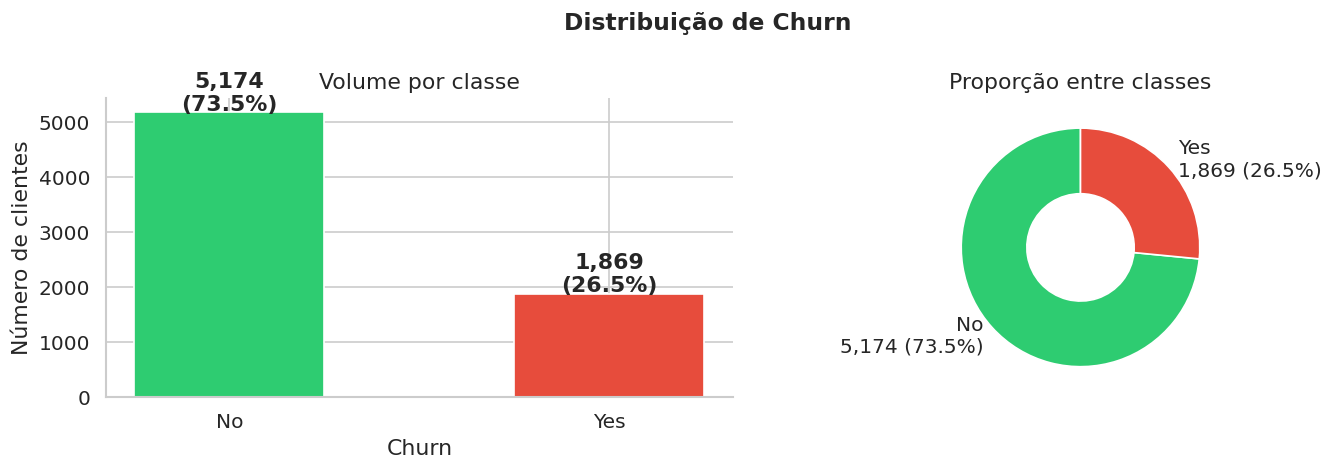

Observacao: o dataset e desbalanceado (26.5% churn).
Acuracia nao e uma metrica adequada. Usar AUC-ROC, Recall e F1.


In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribuição de Churn', fontsize=14, fontweight='bold')

# Gráfico de barras com volume e percentual
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[CHURN_COLORS[c] for c in churn_counts.index],
                   width=0.5, edgecolor='white')
for bar, (lbl, pct) in zip(bars, churn_pct.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{churn_counts[lbl]:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[0].set(title='Volume por classe', xlabel='Churn', ylabel='Número de clientes')

# Gráfico de rosca para proporção
axes[1].pie(churn_counts.values,
            labels=[f'{l}\n{v:,} ({p:.1f}%)' for l, v, p
                    in zip(churn_counts.index, churn_counts.values, churn_pct.values)],
            colors=[CHURN_COLORS[c] for c in churn_counts.index],
            startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white'))
axes[1].set_title('Proporção entre classes')

plt.tight_layout()
plt.show()

print(f'Observacao: o dataset e desbalanceado ({churn_pct["Yes"]:.1f}% churn).')
print('Acuracia nao e uma metrica adequada. Usar AUC-ROC, Recall e F1.')

## Variáveis Numéricas × Churn

As três variáveis numéricas contínuas do dataset são analisadas em conjunto: histograma para ver a distribuição por classe e boxplot para comparar medianas e dispersão.

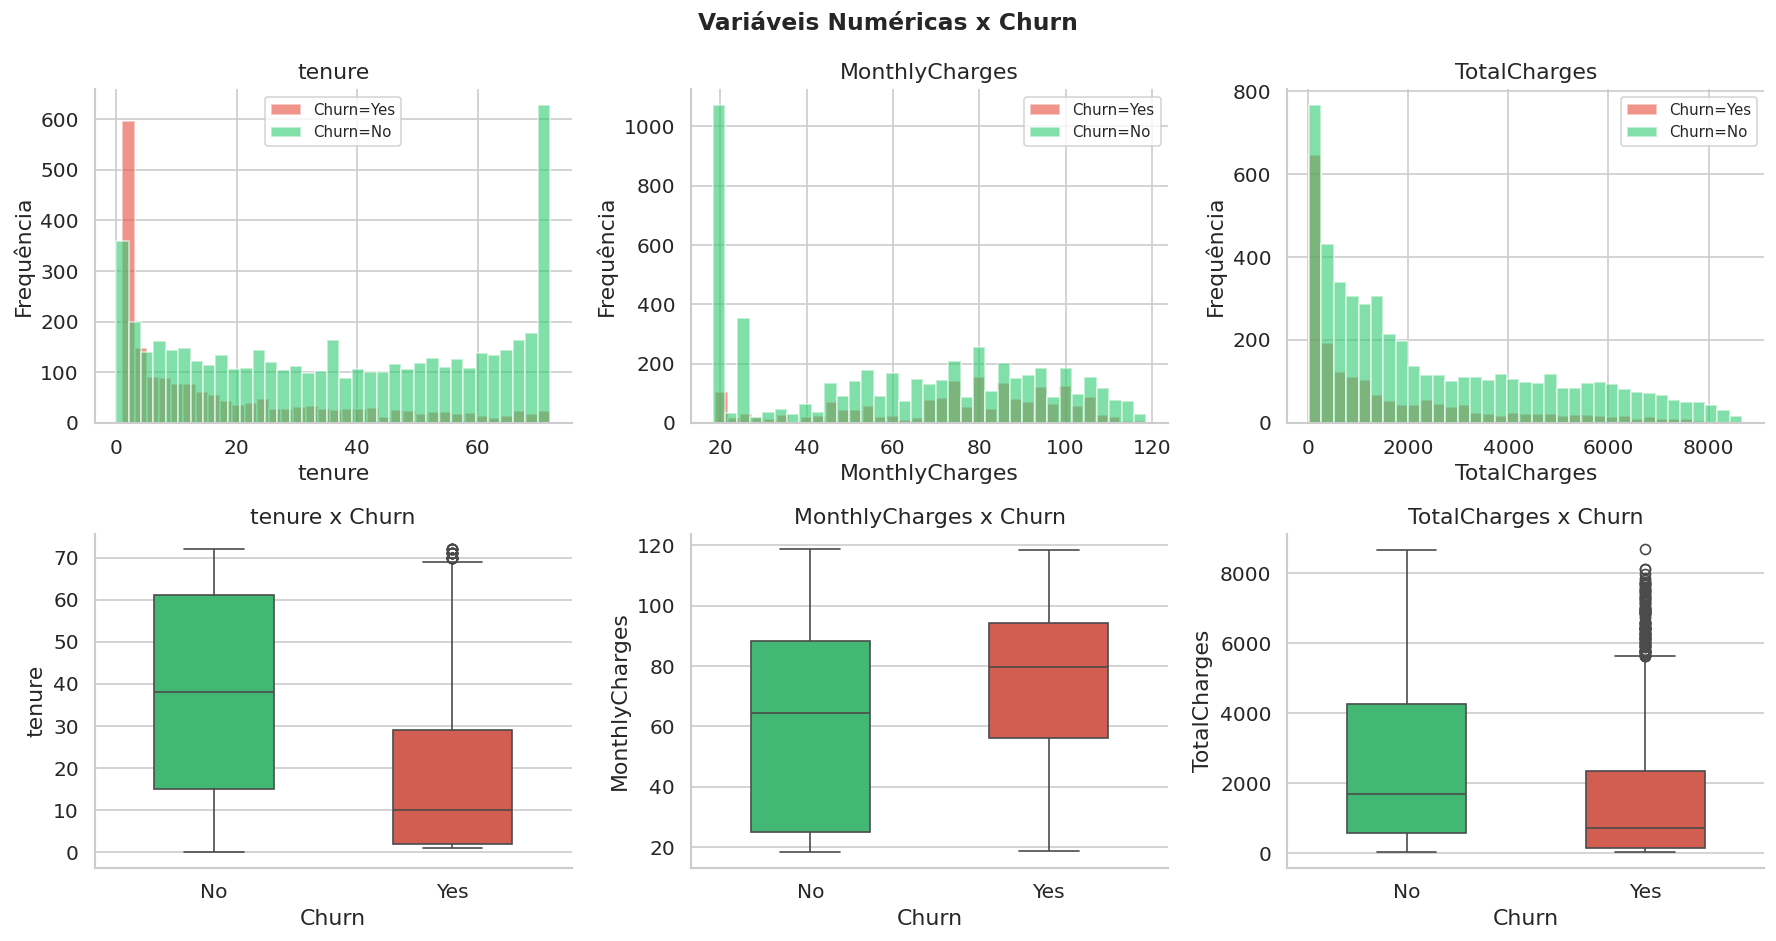

Media por grupo de Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27        2550.0
Yes     17.98           74.44        1531.8


In [9]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Variáveis Numéricas x Churn', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    # Histograma sobreposto por classe
    for val, color in CHURN_COLORS.items():
        axes[0, i].hist(df[df['Churn'] == val][col], bins=35, alpha=0.6,
                        color=color, label=f'Churn={val}', edgecolor='white')
    axes[0, i].set(title=col, xlabel=col, ylabel='Frequência')
    axes[0, i].legend(fontsize=9)

    # Boxplot para comparação de medianas
    sns.boxplot(data=df, x='Churn', y=col, palette=CHURN_COLORS,
                ax=axes[1, i], width=0.5)
    axes[1, i].set(title=f'{col} x Churn')

plt.tight_layout()
plt.show()

print('Media por grupo de Churn:')
print(df.groupby('Churn')[num_cols].mean().round(2))

## Taxa de Churn por Variáveis Categóricas

Para cada categoria, calculamos a proporção de clientes que cancelaram. A linha tracejada representa a taxa média geral de churn (26.5%), servindo como referência. Barras em vermelho indicam categorias com risco acima da média.

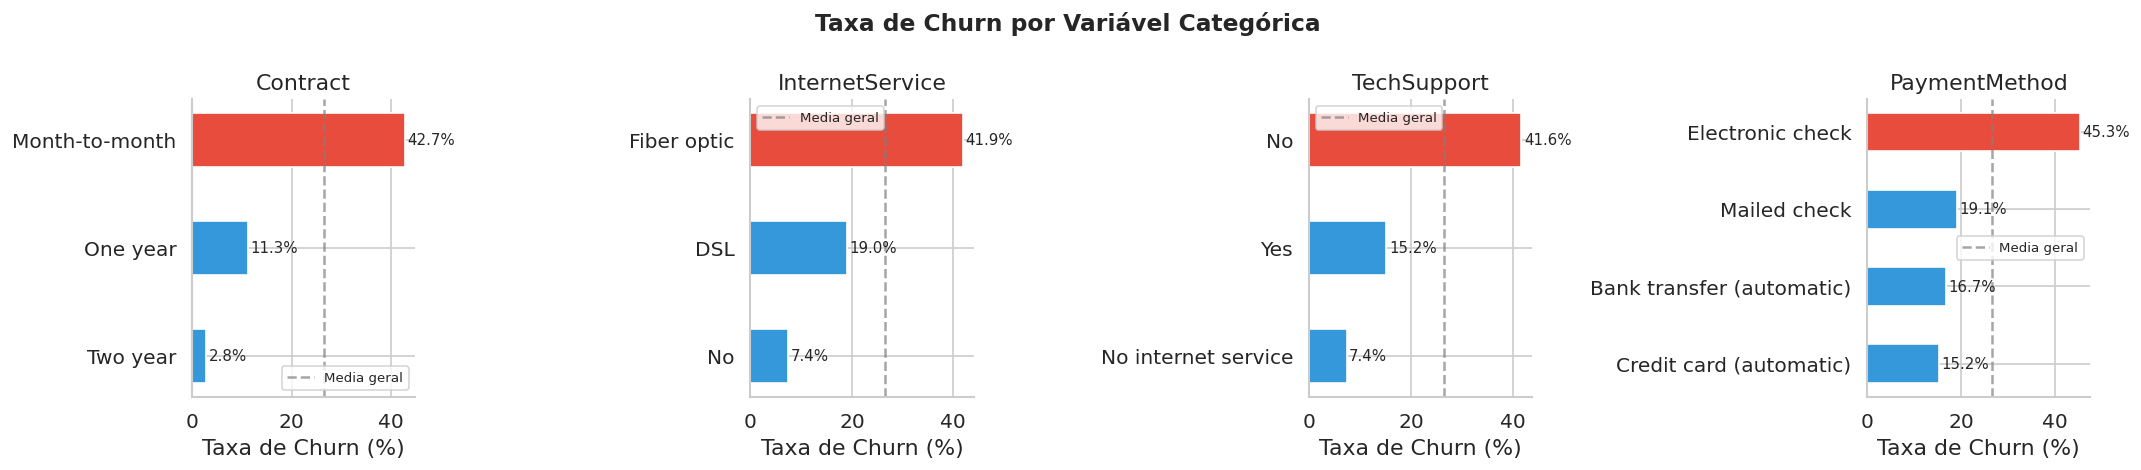

In [10]:
top_cats    = ['Contract', 'InternetService', 'TechSupport', 'PaymentMethod']
media_geral = df['Churn_num'].mean() * 100

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Taxa de Churn por Variável Categórica', fontsize=14, fontweight='bold')

for ax, col in zip(axes, top_cats):
    taxa   = df.groupby(col)['Churn_num'].mean().sort_values() * 100
    colors = [DANGER if v > media_geral else PRIMARY for v in taxa.values]

    ax.barh(taxa.index.astype(str), taxa.values,
            color=colors, height=0.5, edgecolor='white')
    ax.axvline(media_geral, linestyle='--', color='gray', alpha=0.7, label='Media geral')

    for i, v in enumerate(taxa.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

    ax.set(title=col, xlabel='Taxa de Churn (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Tenure — Período Crítico de Retenção

O tempo de contrato é dividido em faixas para entender em qual momento da jornada o cliente tem maior risco de cancelamento. Clientes no início do relacionamento (primeiros 12 meses) são historicamente o grupo de maior risco.

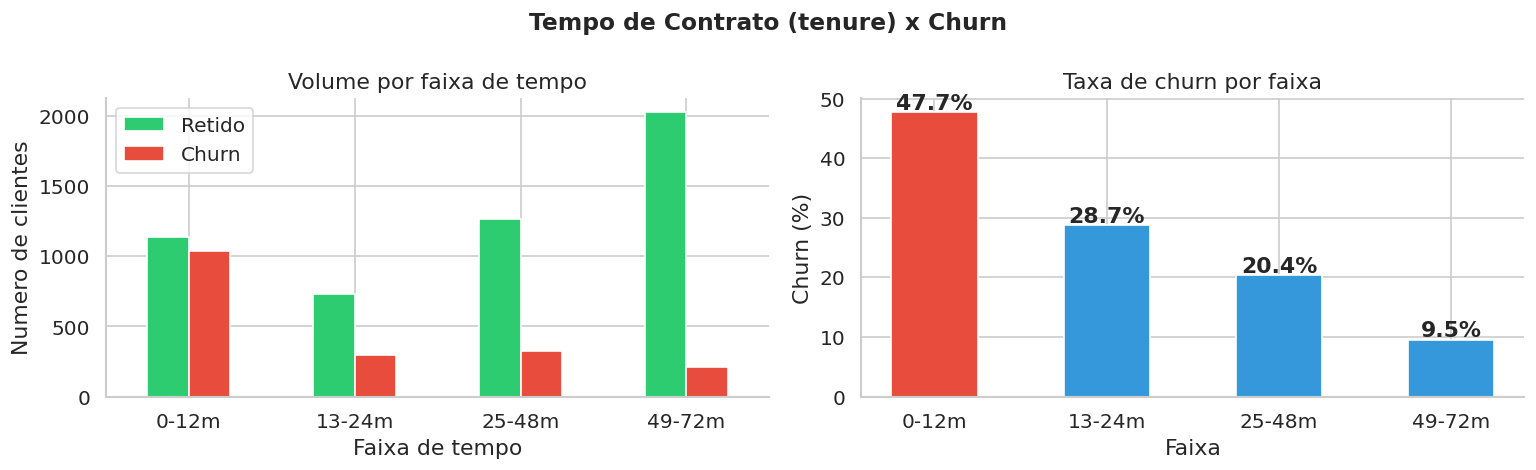

Insight: clientes no primeiro ano de contrato apresentam a maior taxa de churn.
Este grupo deve ser priorizado em campanhas de retencao preventiva.


In [11]:
# Segmentação em faixas de tempo para análise de comportamento
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12m', '13-24m', '25-48m', '49-72m'])

churn_tenure = df.groupby('tenure_group')['Churn_num'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Tempo de Contrato (tenure) x Churn', fontsize=14, fontweight='bold')

# Volume de clientes por faixa, separados por classe
pd.crosstab(df['tenure_group'], df['Churn']).plot(
    kind='bar', ax=axes[0],
    color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
    edgecolor='white', rot=0)
axes[0].set(title='Volume por faixa de tempo',
            xlabel='Faixa de tempo', ylabel='Numero de clientes')
axes[0].legend(['Retido', 'Churn'])

# Taxa de churn por faixa — destaca faixas acima de 30%
bars = axes[1].bar(churn_tenure.index.astype(str), churn_tenure.values,
                   color=[DANGER if v > 30 else PRIMARY for v in churn_tenure.values],
                   width=0.5, edgecolor='white')
for bar, v in zip(bars, churn_tenure.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set(title='Taxa de churn por faixa',
            xlabel='Faixa', ylabel='Churn (%)')

plt.tight_layout()
plt.show()

print('Insight: clientes no primeiro ano de contrato apresentam a maior taxa de churn.')
print('Este grupo deve ser priorizado em campanhas de retencao preventiva.')

## Resumo dos Insights — EDA

In [12]:
insights = {
    'Taxa geral de churn'           : df['Churn_num'].mean() * 100,
    'Churn — contrato mensal'       : df[df['Contract']=='Month-to-month']['Churn_num'].mean() * 100,
    'Churn — contrato bienal'       : df[df['Contract']=='Two year']['Churn_num'].mean() * 100,
    'Churn — primeiros 12 meses'    : df[df['tenure_group']=='0-12m']['Churn_num'].mean() * 100,
    'Churn — internet fibra optica' : df[df['InternetService']=='Fiber optic']['Churn_num'].mean() * 100,
    'Churn — sem suporte tecnico'   : df[df['TechSupport']=='No']['Churn_num'].mean() * 100,
}

print('=' * 52)
print('       PRINCIPAIS INSIGHTS — EDA')
print('=' * 52)
for k, v in insights.items():
    alerta = '[ALTO]' if v > 35 else ('[BAIXO]' if v < 10 else '')
    print(f'  {k:<35} {v:>5.1f}%  {alerta}')
print('=' * 52)

       PRINCIPAIS INSIGHTS — EDA
  Taxa geral de churn                  26.5%  
  Churn — contrato mensal              42.7%  [ALTO]
  Churn — contrato bienal               2.8%  [BAIXO]
  Churn — primeiros 12 meses           47.7%  [ALTO]
  Churn — internet fibra optica        41.9%  [ALTO]
  Churn — sem suporte tecnico          41.6%  [ALTO]


---
# Parte 2 — Feature Engineering

Nesta etapa preparamos o dataset para os algoritmos de machine learning. As principais transformações são:

- Remoção de colunas sem valor preditivo (`customerID`)
- Encoding de variáveis binárias (Yes/No → 1/0)
- One-Hot Encoding de variáveis categóricas com 3+ categorias
- Criação de três novas features derivadas com base nos insights do EDA
- Normalização das variáveis numéricas
- Divisão em conjuntos de treino e teste

## Limpeza e Remoção de Colunas

In [13]:
# customerID é apenas um identificador técnico sem valor preditivo
# Churn_num e tenure_group foram criados para o EDA e não entram na modelagem
df.drop(columns=['customerID', 'Churn_num', 'tenure_group'], inplace=True)

print(f'Shape após limpeza: {df.shape}')

Shape após limpeza: (7043, 20)


## Encoding Binário

In [14]:
# gender recebe mapeamento próprio (Female=0, Male=1)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Demais colunas binárias seguem o padrão No=0, Yes=1
# A variável alvo Churn também é convertida aqui
binarias = ['Partner', 'Dependents', 'PhoneService',
            'PaperlessBilling', 'Churn', 'SeniorCitizen']
for col in binarias:
    df[col] = df[col].map({'No': 0, 'Yes': 1})

print('Encoding binario aplicado.')
df[['gender'] + binarias].head(3)

Encoding binario aplicado.


,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn,SeniorCitizen
0,0,1,0,0,1,0,0
1,1,0,0,1,0,0,0
2,1,0,0,1,1,1,0


## One-Hot Encoding

`drop_first=True` remove uma das categorias geradas por coluna para evitar multicolinearidade — problema que afeta principalmente a Regressão Logística.

In [15]:
categoricas = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df = pd.get_dummies(df, columns=categoricas, drop_first=True)

print(f'Shape apos One-Hot Encoding: {df.shape}')

Shape apos One-Hot Encoding: (7043, 31)


## Features Derivadas

Novas variáveis criadas a partir da combinação de colunas existentes, motivadas pelos padrões encontrados no EDA.

In [16]:
# Gasto médio mensal real: divide o total pelo tempo de contrato
# Para clientes com tenure=0, usamos 1 no denominador para evitar divisão por zero
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Quantidade total de servicos adicionais contratados pelo cliente
# Clientes com mais servicos tendem a ter maior custo de troca (switching cost)
servicos = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
            'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df['num_services'] = df[servicos].sum(axis=1)

# Flag para clientes no primeiro ano — periodo de maior risco identificado no EDA
df['is_new_customer'] = (df['tenure'] <= 12).astype(int)

print('Features criadas: avg_monthly_spend | num_services | is_new_customer')
df[['avg_monthly_spend', 'num_services', 'is_new_customer']].describe().round(2)

Features criadas: avg_monthly_spend | num_services | is_new_customer


,avg_monthly_spend,num_services,is_new_customer
count,7043.00,7043.00,7043.00
mean,64.76,2.04,0.31
std,30.19,1.85,0.46
min,13.78,0.00,0.00
25%,35.94,0.00,0.00
50%,70.34,2.00,0.00
75%,90.17,3.00,1.00
max,121.40,6.00,1.00


## Normalização e Divisão Treino/Teste

In [17]:
# MinMaxScaler escala as variaveis numericas para o intervalo [0, 1]
# Necessario para a Regressao Logistica; nao prejudica Random Forest nem XGBoost
numericas = ['tenure', 'MonthlyCharges', 'TotalCharges',
             'avg_monthly_spend', 'num_services']

scaler        = MinMaxScaler()
df[numericas] = scaler.fit_transform(df[numericas])

X = df.drop(columns=['Churn'])
y = df['Churn']

# stratify=y garante que a proporcao de churn seja mantida em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino : {X_train.shape[0]:,} registros  |  Churn: {y_train.mean()*100:.1f}%')
print(f'Teste  : {X_test.shape[0]:,} registros  |  Churn: {y_test.mean()*100:.1f}%')
print(f'Features: {X.shape[1]}')

Treino : 5,634 registros  |  Churn: 26.5%
Teste  : 1,409 registros  |  Churn: 26.5%
Features: 33


---
# Parte 3 — Modelagem Preditiva

Treinamos três modelos com perfis distintos para cobrir diferentes perspectivas:

- **Regressão Logística**: modelo linear, interpretável, serve como baseline
- **Random Forest**: ensemble baseado em árvores, robusto a ruído e não-linearidades
- **XGBoost**: gradient boosting, estado da arte para dados tabulares

O parâmetro `class_weight='balanced'` / `scale_pos_weight` é aplicado em todos os modelos para lidar com o desbalanceamento de classes sem alterar o dataset original.

## Treinamento com Hiperparâmetros Padrão (Baseline)

In [18]:
# Razao entre classe majoritaria e minoritaria — usada pelo XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    'Regressao Logistica': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42)
}

resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados[nome] = {
        'modelo'    : modelo,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'AUC-ROC'   : roc_auc_score(y_test, y_proba),
        'Recall'    : recall_score(y_test, y_pred),
        'F1'        : f1_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
    }
    print(f'{nome} treinado.')

Regressao Logistica treinado.
Random Forest treinado.
XGBoost treinado.


## Otimização de Hiperparâmetros com Optuna

O Optuna realiza uma busca inteligente no espaço de hiperparâmetros usando o algoritmo TPE (Tree-structured Parzen Estimator), que é mais eficiente do que GridSearchCV por aprender com tentativas anteriores para sugerir os próximos valores a explorar.

Cada `study` roda 50 tentativas (`n_trials`) avaliando o AUC-ROC por validação cruzada de 5 folds no conjunto de treino.

In [19]:
def objective_lr(trial):
    C      = trial.suggest_float('C', 0.01, 10.0, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    model  = LogisticRegression(C=C, solver=solver, class_weight='balanced',
                                max_iter=1000, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()


def objective_rf(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 5),
    }
    model = RandomForestClassifier(**params, class_weight='balanced', random_state=42)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()


def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBClassifier(**params, scale_pos_weight=scale_pos,
                          eval_metric='logloss', random_state=42)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()


estudos = {
    'Regressao Logistica' : (objective_lr,  50),
    'Random Forest'       : (objective_rf,  50),
    'XGBoost'             : (objective_xgb, 50),
}

melhores_params = {}

for nome, (objective, n_trials) in estudos.items():
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    melhores_params[nome] = study.best_params
    print(f'{nome:<25}  Melhor AUC-ROC: {study.best_value:.4f}')
    print(f'  Params: {study.best_params}\n')

Regressao Logistica        Melhor AUC-ROC: 0.8458
  Params: {'C': 9.62986596664757, 'solver': 'saga'}

Random Forest              Melhor AUC-ROC: 0.8459
  Params: {'n_estimators': 457, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 5}

XGBoost                    Melhor AUC-ROC: 0.8489
  Params: {'n_estimators': 181, 'max_depth': 3, 'learning_rate': 0.031640917915161874, 'subsample': 0.6439655280413142, 'colsample_bytree': 0.9193764183999935}



## Retreinamento com os Melhores Hiperparâmetros

In [20]:
modelos_tuned = {
    'Regressao Logistica' : LogisticRegression(
        **melhores_params['Regressao Logistica'],
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(
        **melhores_params['Random Forest'],
        class_weight='balanced', random_state=42),
    'XGBoost'             : XGBClassifier(
        **melhores_params['XGBoost'],
        scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42),
}

resultados_tuned = {}

for nome, modelo in modelos_tuned.items():
    modelo.fit(X_train, y_train)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados_tuned[nome] = {
        'modelo'    : modelo,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'AUC-ROC'   : roc_auc_score(y_test, y_proba),
        'Recall'    : recall_score(y_test, y_pred),
        'F1'        : f1_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
    }
    print(f'{nome} retreinado.')

Regressao Logistica retreinado.
Random Forest retreinado.
XGBoost retreinado.


## Comparativo de Métricas — Antes e Depois do Tuning

As métricas escolhidas para avaliação refletem o contexto do problema:

- **AUC-ROC**: mede a capacidade do modelo de separar as classes em todos os thresholds
- **Recall**: proporção de churns reais que o modelo identificou corretamente — métrica mais crítica no contexto de retenção, pois um falso negativo (churn não detectado) tem alto custo financeiro
- **F1**: equilíbrio entre Recall e Precision
- **Precision**: proporção de alertas de churn que eram churn de fato

In [21]:
metricas = ['AUC-ROC', 'Recall', 'F1', 'Precision']

df_antes  = pd.DataFrame(
    {n: {m: round(r[m], 4) for m in metricas} for n, r in resultados.items()}).T
df_depois = pd.DataFrame(
    {n: {m: round(r[m], 4) for m in metricas} for n, r in resultados_tuned.items()}).T

print('ANTES do tuning (hiperparametros padrao):')
print(df_antes.to_string())
print()
print('DEPOIS do tuning (Optuna — 50 trials por modelo):')
print(df_depois.to_string())
print()
print('Ganho em AUC-ROC apos tuning:')
for nome in df_antes.index:
    ganho = df_depois.loc[nome, 'AUC-ROC'] - df_antes.loc[nome, 'AUC-ROC']
    sinal = '[+]' if ganho > 0 else '[=]'
    print(f'  {sinal} {nome:<25} {ganho:+.4f}')

ANTES do tuning (hiperparametros padrao):
                     AUC-ROC  Recall      F1  Precision
Regressao Logistica   0.8411  0.7914  0.6135     0.5008
Random Forest         0.8261  0.4733  0.5380     0.6232
XGBoost               0.8188  0.6578  0.5985     0.5491

DEPOIS do tuning (Optuna — 50 trials por modelo):
                     AUC-ROC  Recall      F1  Precision
Regressao Logistica   0.8409  0.7941  0.6136     0.5000
Random Forest         0.8432  0.7620  0.6340     0.5429
XGBoost               0.8470  0.8182  0.6316     0.5143

Ganho em AUC-ROC apos tuning:
  [=] Regressao Logistica       -0.0002
  [+] Random Forest             +0.0171
  [+] XGBoost                   +0.0282


## Curvas ROC

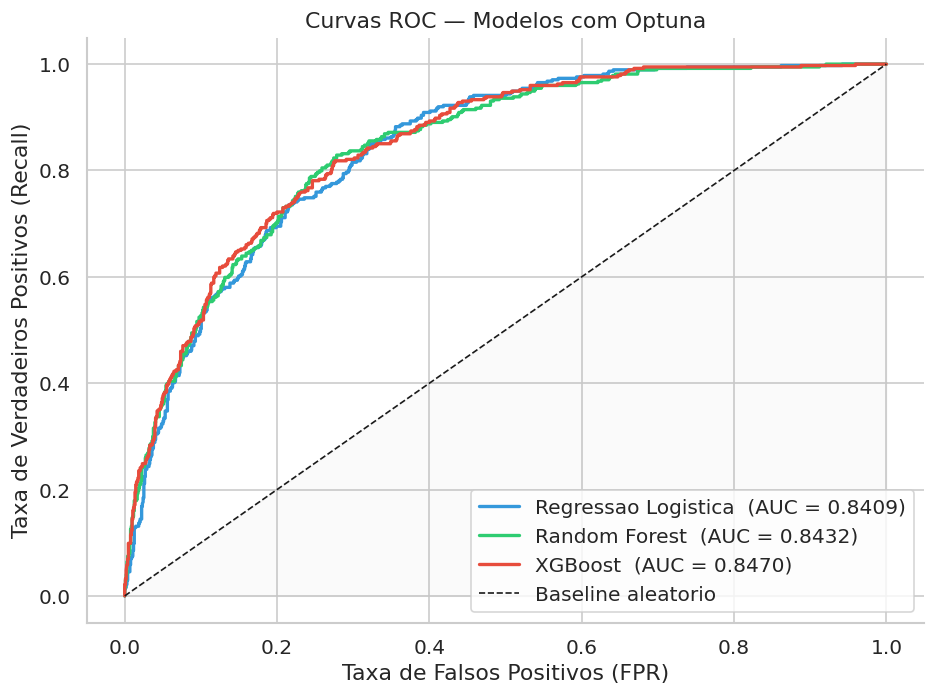

In [22]:
cores_modelos = ['#3498DB', '#2ECC71', '#E74C3C']

fig, ax = plt.subplots(figsize=(8, 6))

for (nome, res), cor in zip(resultados_tuned.items(), cores_modelos):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=cor, linewidth=2,
            label=f"{nome}  (AUC = {res['AUC-ROC']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set(title='Curvas ROC — Modelos com Optuna',
       xlabel='Taxa de Falsos Positivos (FPR)',
       ylabel='Taxa de Verdadeiros Positivos (Recall)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Matrizes de Confusão

A matriz de confusão mostra em detalhe os tipos de erro de cada modelo:

- **Falso Negativo (FN)**: cliente que vai dar churn, mas o modelo não detectou — o mais custoso
- **Falso Positivo (FP)**: cliente retido que o modelo sinalizou como churn — gera custo de campanha desnecessário

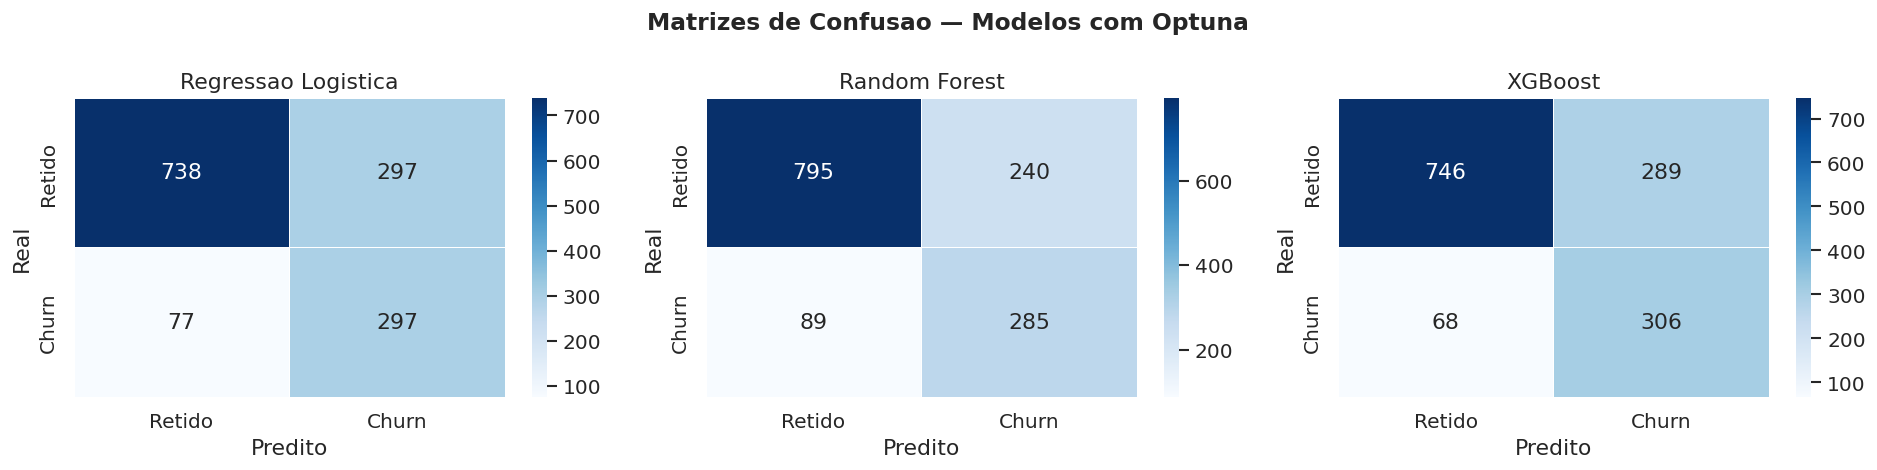

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Matrizes de Confusao — Modelos com Optuna', fontsize=14, fontweight='bold')

for ax, (nome, res) in zip(axes, resultados_tuned.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retido', 'Churn'],
                yticklabels=['Retido', 'Churn'],
                linewidths=0.5)
    ax.set(title=nome, xlabel='Predito', ylabel='Real')

plt.tight_layout()
plt.show()

## Feature Importance

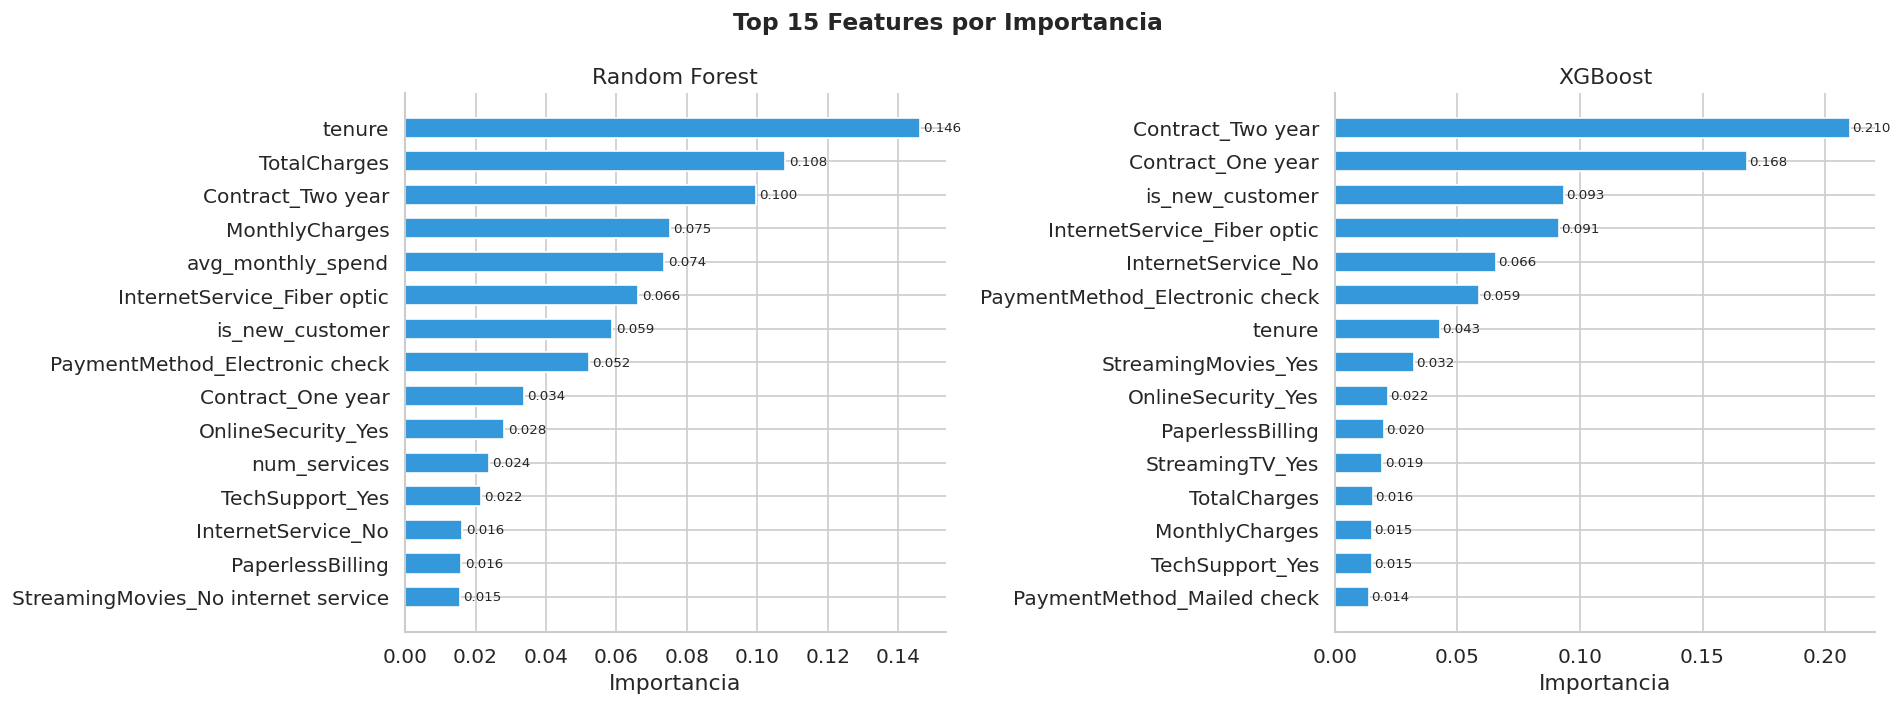

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Features por Importancia', fontsize=14, fontweight='bold')

for ax, nome in zip(axes, ['Random Forest', 'XGBoost']):
    modelo      = resultados_tuned[nome]['modelo']
    importancias = pd.Series(modelo.feature_importances_, index=X.columns)
    top15       = importancias.sort_values(ascending=True).tail(15)

    bars = ax.barh(top15.index, top15.values,
                   color=PRIMARY, edgecolor='white', height=0.6)
    for bar in bars:
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)
    ax.set(title=nome, xlabel='Importancia')

plt.tight_layout()
plt.show()

## Validação Cruzada — Robustez dos Modelos

A validação cruzada verifica se as métricas obtidas no teste são consistentes ou se houve variação por sorte na divisão dos dados.

In [25]:
print(f'{"Modelo":<25} {"Media":>8} {"Desvio":>8} {"Min":>8} {"Max":>8}')
print('-' * 60)

for nome, res in resultados_tuned.items():
    scores = cross_val_score(res['modelo'], X, y, cv=5, scoring='roc_auc')
    print(f'{nome:<25} {scores.mean():>8.4f} {scores.std():>8.4f}'
          f' {scores.min():>8.4f} {scores.max():>8.4f}')

Modelo                       Media   Desvio      Min      Max
------------------------------------------------------------
Regressao Logistica         0.8452   0.0112   0.8301   0.8610
Random Forest               0.8459   0.0130   0.8258   0.8606
XGBoost                     0.8489   0.0109   0.8316   0.8617


## Impacto Financeiro

Traduzimos as predições do modelo em valor financeiro estimado. A análise considera o custo de cada tipo de erro e o retorno esperado de uma campanha de retenção bem-sucedida.

**Premissas:**
- Receita média mensal por cliente: USD 65 (baseado nos dados do dataset)
- Horizonte de retenção estimado: 12 meses
- Custo de uma ação de retenção (ligação, desconto, benefício): USD 50 por cliente

In [26]:
receita_media_mensal = 65.0
meses_retidos        = 12
custo_campanha       = 50.0
valor_cliente        = receita_media_mensal * meses_retidos

print('=' * 57)
print('        IMPACTO FINANCEIRO — MODELO DE CHURN')
print('=' * 57)
print(f'  Receita media mensal por cliente : USD {receita_media_mensal:.0f}')
print(f'  Valor estimado de retencao (12m) : USD {valor_cliente:.0f}')
print(f'  Custo da campanha de retencao    : USD {custo_campanha:.0f}')
print()

for nome, res in resultados_tuned.items():
    cm          = confusion_matrix(y_test, res['y_pred'])
    vp          = cm[1][1]  # churns corretamente identificados
    fp          = cm[0][1]  # retidos sinalizados incorretamente como churn
    economia    = vp * valor_cliente
    custo_total = (vp + fp) * custo_campanha
    lucro_liq   = economia - custo_total

    print(f'  {nome}')
    print(f'    Churns detectados   : {vp}')
    print(f'    Economia bruta      : USD {economia:,.0f}')
    print(f'    Custo das campanhas : USD {custo_total:,.0f}')
    print(f'    Lucro liquido       : USD {lucro_liq:,.0f}')
    print()

print('=' * 57)
print('  * Estimativas com base no conjunto de teste (20% do total).')

        IMPACTO FINANCEIRO — MODELO DE CHURN
  Receita media mensal por cliente : USD 65
  Valor estimado de retencao (12m) : USD 780
  Custo da campanha de retencao    : USD 50

  Regressao Logistica
    Churns detectados   : 297
    Economia bruta      : USD 231,660
    Custo das campanhas : USD 29,700
    Lucro liquido       : USD 201,960

  Random Forest
    Churns detectados   : 285
    Economia bruta      : USD 222,300
    Custo das campanhas : USD 26,250
    Lucro liquido       : USD 196,050

  XGBoost
    Churns detectados   : 306
    Economia bruta      : USD 238,680
    Custo das campanhas : USD 29,750
    Lucro liquido       : USD 208,930

  * Estimativas com base no conjunto de teste (20% do total).


---
# Parte 4 — Interpretabilidade com SHAP

O SHAP (SHapley Additive exPlanations) é um método baseado em teoria dos jogos que atribui a cada feature uma contribuição individual para cada predição do modelo. Diferente da feature importance tradicional, o SHAP mostra **quanto** e **em qual direção** cada variável empurra a predição.

Usamos o XGBoost como modelo de referência por ter obtido o melhor AUC-ROC após o tuning.

## Cálculo dos SHAP Values

In [27]:
modelo_final = resultados_tuned['XGBoost']['modelo']

# TreeExplainer é otimizado para modelos baseados em árvores (XGBoost, LightGBM, Random Forest)
explainer   = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values calculados para {X_test.shape[0]:,} registros e {X_test.shape[1]} features.')

SHAP values calculados para 1,409 registros e 33 features.


## Summary Plot — Visão Global

O summary plot mostra as features ordenadas pela importância média (eixo X = impacto no output do modelo). Cada ponto é um cliente do conjunto de teste:

- **Cor vermelha**: valor alto da feature
- **Cor azul**: valor baixo da feature
- **Posição no eixo X**: direção e magnitude do impacto na predição de churn

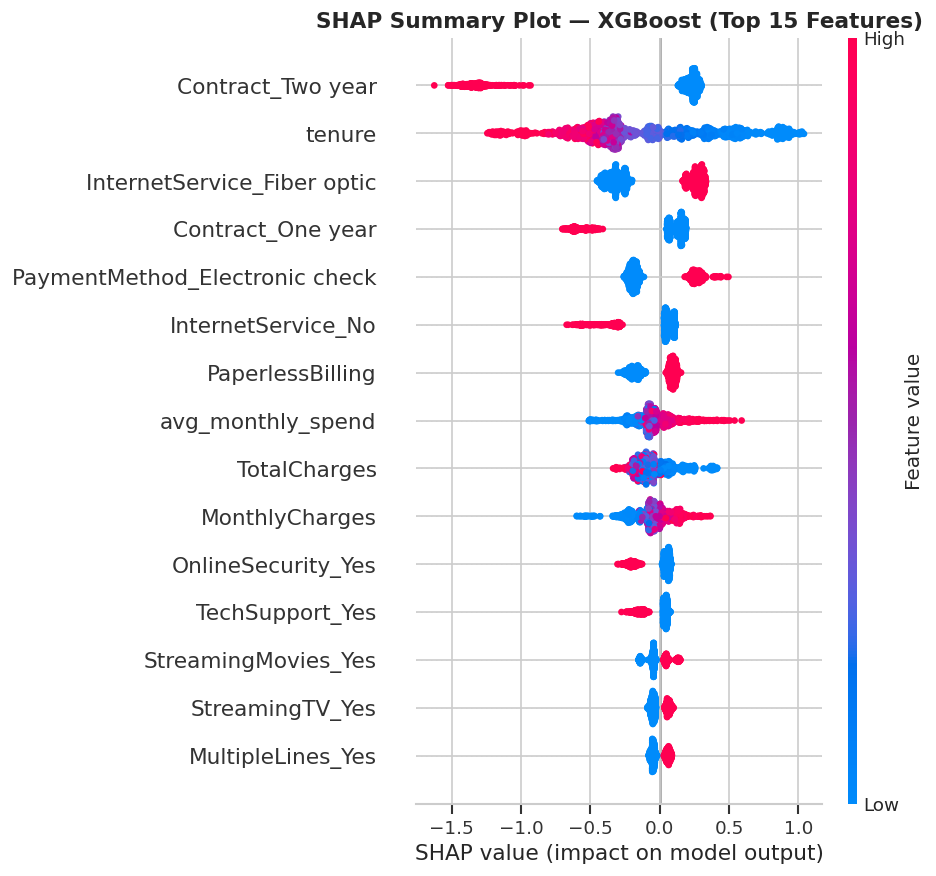

In [28]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary Plot — XGBoost (Top 15 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bar Plot — Importância Média Absoluta

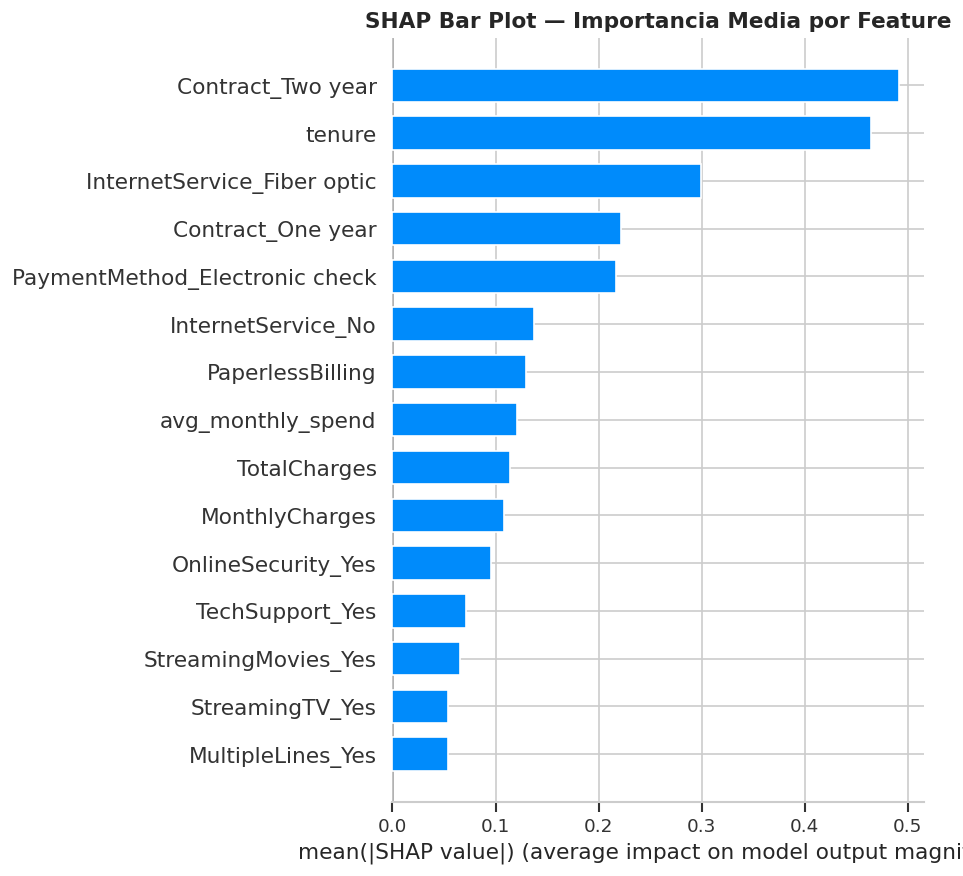

In [29]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Bar Plot — Importancia Media por Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Dependence Plot — Relação Feature × SHAP Value

Mostra como o valor de `tenure` impacta a predição de churn para cada cliente. Pontos à esquerda (tempo curto de contrato) tendem a ter SHAP values positivos — ou seja, contribuem para aumentar a probabilidade de churn.

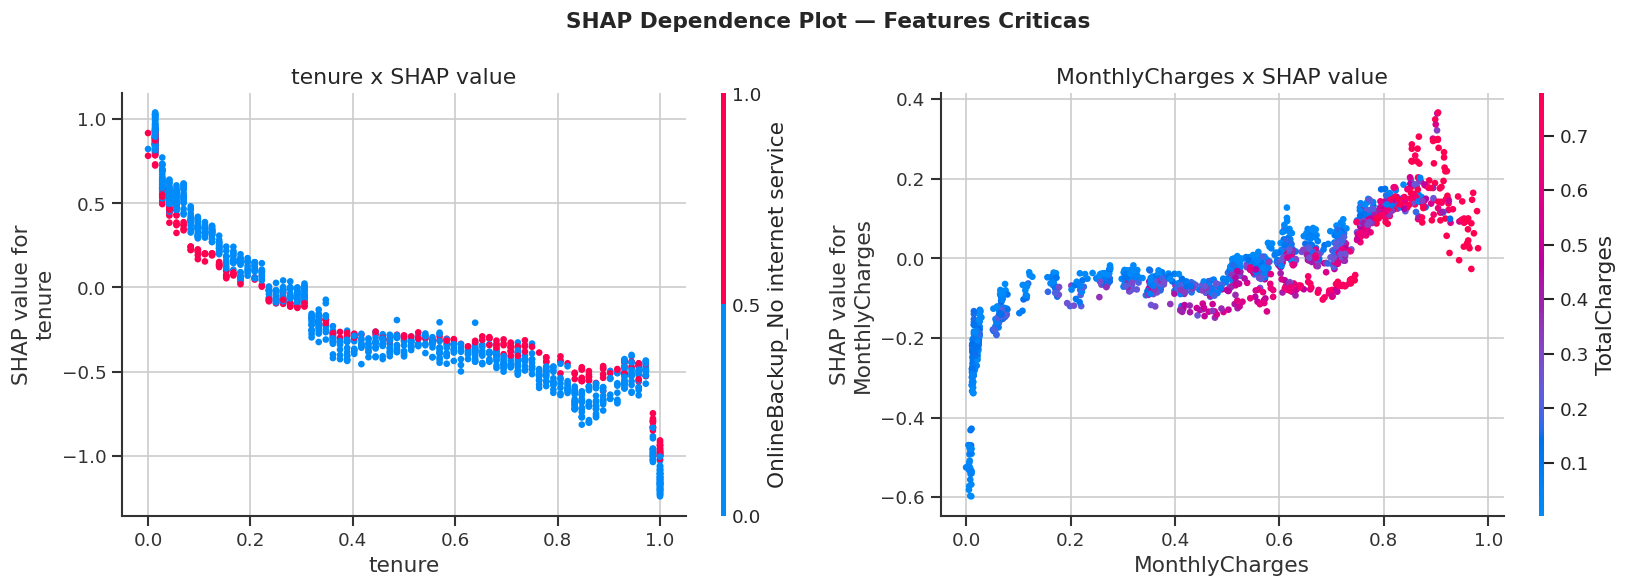

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SHAP Dependence Plot — Features Criticas', fontsize=13, fontweight='bold')

# tenure: quanto mais novo o cliente, maior o impacto no churn
shap.dependence_plot('tenure', shap_values, X_test,
                     ax=axes[0], show=False)
axes[0].set_title('tenure x SHAP value')

# MonthlyCharges: cobranca alta associada a maior churn
shap.dependence_plot('MonthlyCharges', shap_values, X_test,
                     ax=axes[1], show=False)
axes[1].set_title('MonthlyCharges x SHAP value')

plt.tight_layout()
plt.show()

## Waterfall Plot — Explicando uma Predição Individual

O waterfall plot mostra, para um único cliente, quais features contribuíram para aumentar ou reduzir a probabilidade de churn em relação ao valor base (media do modelo).

Cliente selecionado: indice 1090
Probabilidade de churn predita: 94.89%
Classe real: Churn


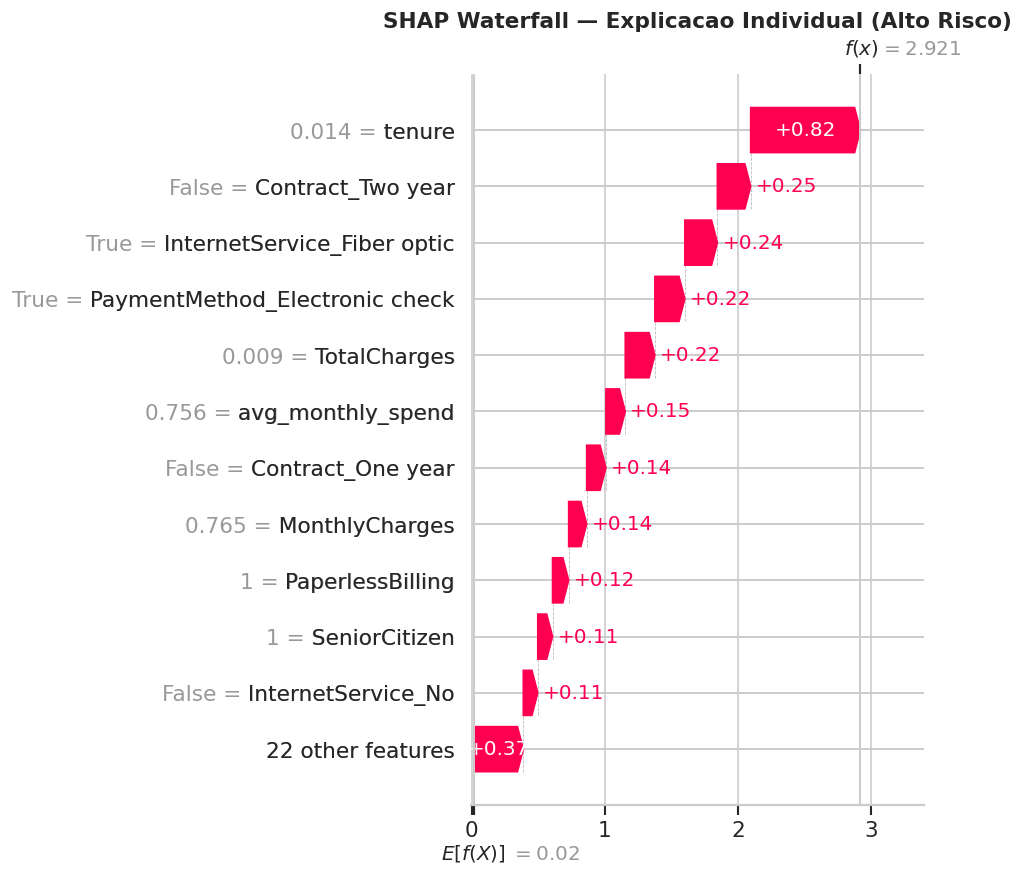

In [31]:
# Selecionamos um cliente com alta probabilidade de churn para a explicacao
y_proba_test  = resultados_tuned['XGBoost']['y_proba']
idx_alto_risco = np.argmax(y_proba_test)  # cliente com maior probabilidade predita

print(f'Cliente selecionado: indice {idx_alto_risco}')
print(f'Probabilidade de churn predita: {y_proba_test[idx_alto_risco]:.2%}')
print(f'Classe real: {"Churn" if y_test.iloc[idx_alto_risco] == 1 else "Retido"}')

# Waterfall plot para o cliente selecionado
shap_explanation = shap.Explanation(
    values      = shap_values[idx_alto_risco],
    base_values = explainer.expected_value,
    data        = X_test.iloc[idx_alto_risco],
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, max_display=12, show=False)
plt.title('SHAP Waterfall — Explicacao Individual (Alto Risco)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Force Plot — Visualização Compacta da Predição

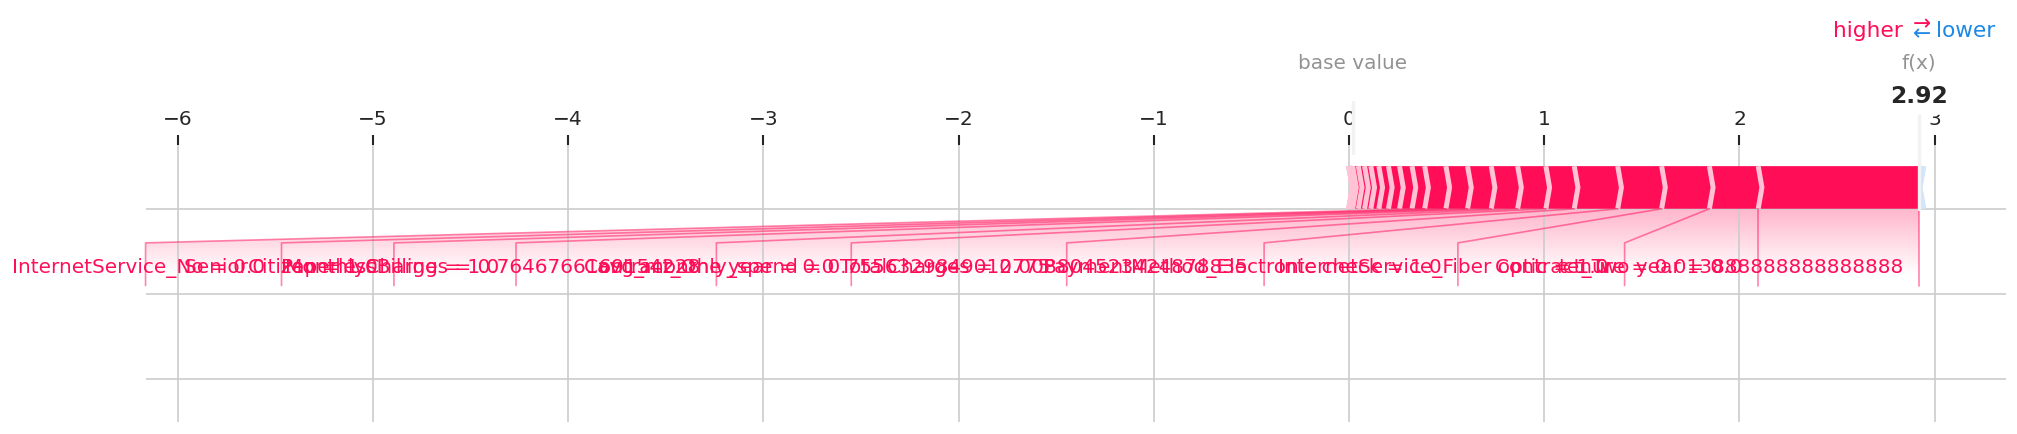

In [32]:
# Force plot: representacao horizontal das forcas que empurram a predicao
# Vermelho = features que aumentam a probabilidade de churn
# Azul     = features que reduzem a probabilidade de churn
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_alto_risco],
    X_test.iloc[idx_alto_risco],
    feature_names=X_test.columns.tolist(),
    matplotlib=True
)

---
## Conclusões Finais

In [34]:
melhor_auc    = df_depois['AUC-ROC'].idxmax()
melhor_recall = df_depois['Recall'].idxmax()

print('=' * 57)
print('              CONCLUSOES DO PROJETO')
print('=' * 57)
print()
print('EDA')
print('  26.5% dos clientes cancelaram — dataset desbalanceado')
print('  Contrato mensal é o maior preditor de churn (42.7%)')
print('  Clientes novos (menos de 12 meses) tem risco dobrado de sair')
print('  Internet via fibra optica e ausencia de suporte tecnico elevam churn')
print()
print('Modelagem')
print(f'  Melhor AUC-ROC : {melhor_auc} ({df_depois.loc[melhor_auc, "AUC-ROC"]:.4f})')
print(f'  Melhor Recall  : {melhor_recall} ({df_depois.loc[melhor_recall, "Recall"]:.4f})')
print(f'  Otimizacao     : Optuna (50 trials por modelo, 5-fold CV)')
print()
print('Interpretabilidade (SHAP)')
print('  tenure e MonthlyCharges sao as features de maior impacto individual')
print('  Contrato mensal e ausencia de suporte tecnico elevam o score de churn')
print('  Clientes com muitos servicos contratados tem menor probabilidade de sair')
print()
print('Recomendacoes de Negocio')
print('  Priorizar campanhas nos primeiros 12 meses de contrato')
print('  Oferecer migracao para contratos anuais a clientes de alto risco')
print('  Incentivar contratacao de suporte tecnico como fator de retencao')
print('=' * 57)

              CONCLUSOES DO PROJETO

EDA
  26.5% dos clientes cancelaram — dataset desbalanceado
  Contrato mensal é o maior preditor de churn (42.7%)
  Clientes novos (menos de 12 meses) tem risco dobrado de sair
  Internet via fibra optica e ausencia de suporte tecnico elevam churn

Modelagem
  Melhor AUC-ROC : XGBoost (0.8470)
  Melhor Recall  : XGBoost (0.8182)
  Otimizacao     : Optuna (50 trials por modelo, 5-fold CV)

Interpretabilidade (SHAP)
  tenure e MonthlyCharges sao as features de maior impacto individual
  Contrato mensal e ausencia de suporte tecnico elevam o score de churn
  Clientes com muitos servicos contratados tem menor probabilidade de sair

Recomendacoes de Negocio
  Priorizar campanhas nos primeiros 12 meses de contrato
  Oferecer migracao para contratos anuais a clientes de alto risco
  Incentivar contratacao de suporte tecnico como fator de retencao
